## 🧠 EEG Emotion Prediction

Given *EEG data from subjects who were watching movies*, let's try to predict the **emotional state** of a subject during a given movie.

We will use a TensorFlow recurrent neural network to make our predictions.

Data source: https://www.kaggle.com/datasets/birdy654/eeg-brainwave-dataset-feeling-emotions

### Importing Libraries

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split

import tensorflow as tf

from sklearn.metrics import confusion_matrix, classification_report

pd.set_option('display.max_columns', None)

In [5]:
data = pd.read_csv('archive/emotions.csv')
data

# mean_0_a  mean_1_a  mean_2_a  mean_3_a  mean_4_a  mean_d_0_a  \
0          4.620      30.3    -356.0     15.60      26.3       1.070   
1         28.800      33.1      32.0     25.80      22.8       6.550   
2          8.900      29.4    -416.0     16.70      23.7      79.900   
3         14.900      31.6    -143.0     19.80      24.3      -0.584   
4         28.300      31.3      45.2     27.30      24.5      34.800   
...          ...       ...       ...       ...       ...         ...   
2127      32.400      32.2      32.2     30.80      23.4       1.640   
2128      16.300      31.3    -284.0     14.30      23.9       4.200   
2129      -0.547      28.3    -259.0     15.80      26.7       9.080   
2130      16.800      19.9    -288.0      8.34      26.0       2.460   
2131      27.000      32.0      31.8     25.00      28.9       4.990   

      mean_d_1_a  mean_d_2_a  mean_d_3_a  mean_d_4_a  mean_d_0_a2  \
0          0.411     -15.700       2.060        3.15         2.15   
1          1.680       2.880       3.830       -4.82        25.60   
2          3.360      90.200      89.900        2.03         7.75   
3         -0.284       8.820       2.300       -1.97        17.30   
4         -5.790       3.060      41.400        5.52        26.10   
...          ...         ...         ...         ...          ...   
2127      -2.030       0.647      -0.121       -1.10        33.30   
2128       1.090       4.460       4.720        6.63       -39.40   
2129       6.900      12.700       2.030        4.64        -1.26   
2130       1.580     -16.000       1.690        4.74        20.90   
2131       1.950       6.210       3.490       -3.51        27.50   

      mean_d_1_a2  mean_d_2_a2  mean_d_3_a2  mean_d_4_a2  mean_d_5_a  \
0            29.5       -353.0        14.40         21.5        5.98   
1            32.8         29.6        21.50         17.4       25.50   
2            30.1       -441.0         9.89         25.3      -68.90   
3            32.0       -148.0        20.40         22.8       13.20   
4            34.3         43.7        23.70         20.6       -3.87   
...           ...          ...          ...          ...         ...   
2127         33.4         31.0        32.30         18.6       30.00   
2128         32.5       -287.0       -42.10         19.2       66.40   
2129         27.2       -254.0        12.50         23.1       -8.82   
2130         21.1       -285.0        11.00         18.8       10.50   
2131         32.1         29.8        24.80         31.3       21.60   

      mean_d_6_a  mean_d_7_a  mean_d_8_a  mean_d_9_a  mean_d_10_a  \
0           30.7      -343.0       14.70        27.9        3.170   
1           31.7        31.5       26.20        32.9       31.800   
2           25.3      -481.0      -65.40        20.0       79.800   
3           31.5      -147.0       16.90        27.7       15.700   
4           34.1        43.7      -10.00        22.9       59.400   
...          ...         ...         ...         ...          ...   
2127        33.0        32.6       29.50        29.1       32.000   
2128        29.0      -286.0       64.50        22.0       19.400   
2129        22.4      -275.0       17.10        25.6        0.367   
2130        17.2      -275.0        4.09        28.4       19.500   
2131        30.0        27.7       21.80        30.0       30.000   

      mean_d_11_a  mean_d_12_a  mean_d_13_a  mean_d_14_a  mean_d_15_a  \
0            32.2       -368.0        15.90         36.4         7.08   
1            33.1         33.2        28.50         26.8        32.40   
2            31.0       -408.0        91.90         29.5        18.80   
3            30.7       -142.0        20.70         22.8        13.60   
4            26.7         60.3        64.70         26.9        32.30   
...           ...          ...          ...          ...          ...   
2127         29.9         32.6        28.50         24.9        34.50   
2128         31.1       -280.0    

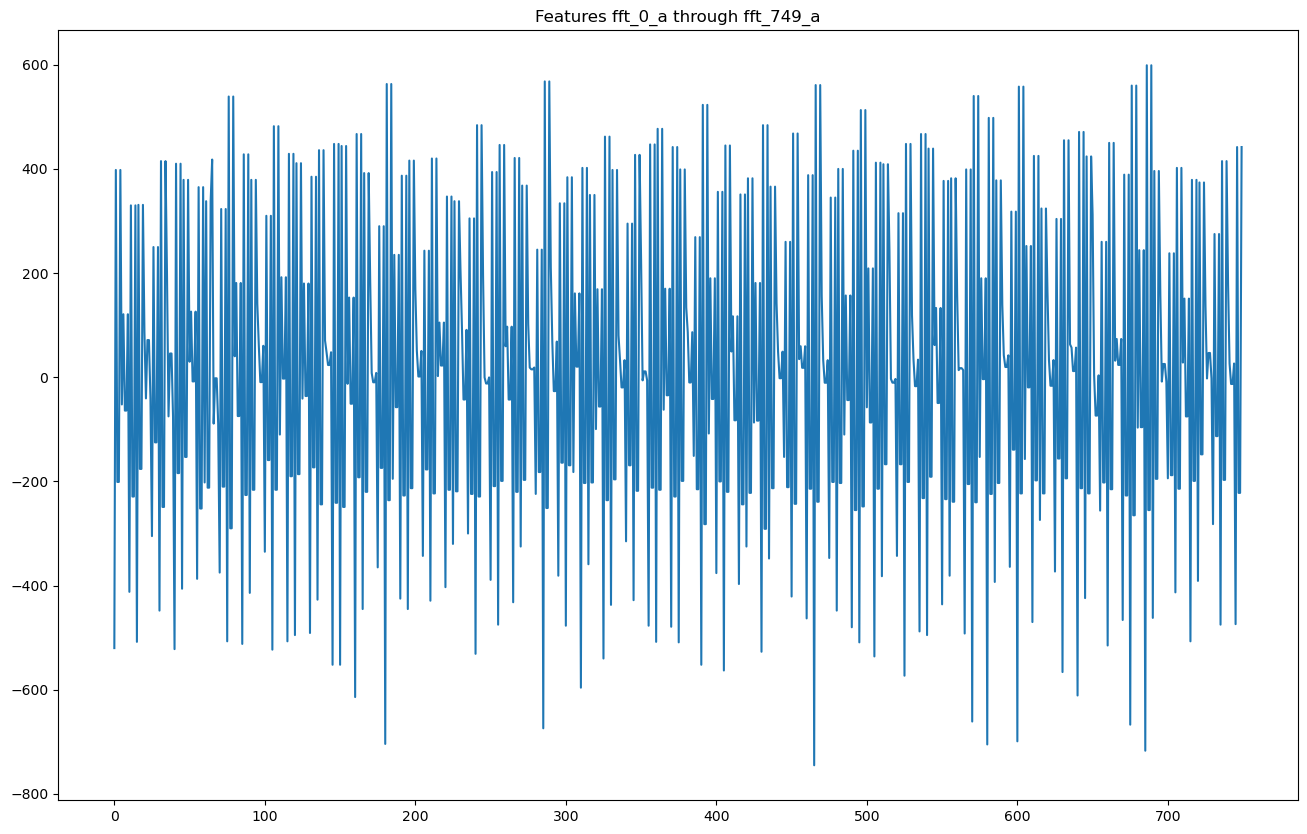

In [6]:
sample = data.loc[0, 'fft_0_a': 'fft_749_a']

plt.figure(figsize=(16,10))

plt.plot(range(len(sample)), sample)
plt.title('Features fft_0_a through fft_749_a')
plt.show()

### Preprocessing

In [9]:
df = data.copy()

In [10]:
df['label'].value_counts()

label
NEUTRAL     716
NEGATIVE    708
POSITIVE    708
Name: count, dtype: int64

In [8]:
label_mapping = {
    'NEGATIVE': 0,
    'NEUTRAL': 1,
    'POSITIVE': 2
}

In [11]:
y = df['label'].copy()
X = df.drop('label', axis=1).copy()

In [12]:
y

0       NEGATIVE
1        NEUTRAL
2       POSITIVE
3       POSITIVE
4        NEUTRAL
          ...   
2127     NEUTRAL
2128    POSITIVE
2129    NEGATIVE
2130    NEGATIVE
2131     NEUTRAL
Name: label, Length: 2132, dtype: object

In [17]:
y = y.replace(label_mapping)
y

/tmp/ipykernel_6974/130430313.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace(label_mapping)


0       0
1       1
2       2
3       2
4       1
       ..
2127    1
2128    2
2129    0
2130    0
2131    1
Name: label, Length: 2132, dtype: int64

In [18]:
X

# mean_0_a  mean_1_a  mean_2_a  mean_3_a  mean_4_a  mean_d_0_a  \
0          4.620      30.3    -356.0     15.60      26.3       1.070   
1         28.800      33.1      32.0     25.80      22.8       6.550   
2          8.900      29.4    -416.0     16.70      23.7      79.900   
3         14.900      31.6    -143.0     19.80      24.3      -0.584   
4         28.300      31.3      45.2     27.30      24.5      34.800   
...          ...       ...       ...       ...       ...         ...   
2127      32.400      32.2      32.2     30.80      23.4       1.640   
2128      16.300      31.3    -284.0     14.30      23.9       4.200   
2129      -0.547      28.3    -259.0     15.80      26.7       9.080   
2130      16.800      19.9    -288.0      8.34      26.0       2.460   
2131      27.000      32.0      31.8     25.00      28.9       4.990   

      mean_d_1_a  mean_d_2_a  mean_d_3_a  mean_d_4_a  mean_d_0_a2  \
0          0.411     -15.700       2.060        3.15         2.15   
1          1.680       2.880       3.830       -4.82        25.60   
2          3.360      90.200      89.900        2.03         7.75   
3         -0.284       8.820       2.300       -1.97        17.30   
4         -5.790       3.060      41.400        5.52        26.10   
...          ...         ...         ...         ...          ...   
2127      -2.030       0.647      -0.121       -1.10        33.30   
2128       1.090       4.460       4.720        6.63       -39.40   
2129       6.900      12.700       2.030        4.64        -1.26   
2130       1.580     -16.000       1.690        4.74        20.90   
2131       1.950       6.210       3.490       -3.51        27.50   

      mean_d_1_a2  mean_d_2_a2  mean_d_3_a2  mean_d_4_a2  mean_d_5_a  \
0            29.5       -353.0        14.40         21.5        5.98   
1            32.8         29.6        21.50         17.4       25.50   
2            30.1       -441.0         9.89         25.3      -68.90   
3            32.0       -148.0        20.40         22.8       13.20   
4            34.3         43.7        23.70         20.6       -3.87   
...           ...          ...          ...          ...         ...   
2127         33.4         31.0        32.30         18.6       30.00   
2128         32.5       -287.0       -42.10         19.2       66.40   
2129         27.2       -254.0        12.50         23.1       -8.82   
2130         21.1       -285.0        11.00         18.8       10.50   
2131         32.1         29.8        24.80         31.3       21.60   

      mean_d_6_a  mean_d_7_a  mean_d_8_a  mean_d_9_a  mean_d_10_a  \
0           30.7      -343.0       14.70        27.9        3.170   
1           31.7        31.5       26.20        32.9       31.800   
2           25.3      -481.0      -65.40        20.0       79.800   
3           31.5      -147.0       16.90        27.7       15.700   
4           34.1        43.7      -10.00        22.9       59.400   
...          ...         ...         ...         ...          ...   
2127        33.0        32.6       29.50        29.1       32.000   
2128        29.0      -286.0       64.50        22.0       19.400   
2129        22.4      -275.0       17.10        25.6        0.367   
2130        17.2      -275.0        4.09        28.4       19.500   
2131        30.0        27.7       21.80        30.0       30.000   

      mean_d_11_a  mean_d_12_a  mean_d_13_a  mean_d_14_a  mean_d_15_a  \
0            32.2       -368.0        15.90         36.4         7.08   
1            33.1         33.2        28.50         26.8        32.40   
2            31.0       -408.0        91.90         29.5        18.80   
3            30.7       -142.0        20.70         22.8        13.60   
4            26.7         60.3        64.70         26.9        32.30   
...           ...          ...          ...          ...          ...   
2127         29.9         32.6        28.50         24.9        34.50   
2128         31.1       -280.0    

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=123)

### Modeling

In [47]:
inputs = tf.keras.Input(shape=(X_train.shape[1],))

expanded = tf.keras.layers.Reshape((X_train.shape[1], 1))(inputs)

gru = tf.keras.layers.GRU(256, return_sequences=True)(expanded)

flatten = tf.keras.layers.Flatten()(gru)

outputs = tf.keras.layers.Dense(3, activation='softmax')(flatten)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

print(model.summary())

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 2548)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 2548, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 2548, 256)      │       198,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 652288)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │     1,956,867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,155,779 (8.22 MB)

 Trainable params: 2,155,779 (8.22 MB)

 Non-trainable params: 0 (0.00 B)

None


In [48]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    batch_size=32,
    epochs=50,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )
    ]
)

Epoch 1/50


W0000 00:00:1790520962.646106    9258 cpu_allocator_impl.cc:82] Allocation of 83492864 exceeds 10% of free system memory.
W0000 00:00:1790520962.969092    9258 cpu_allocator_impl.cc:82] Allocation of 83492864 exceeds 10% of free system memory.
W0000 00:00:1790520963.151935    9259 cpu_allocator_impl.cc:82] Allocation of 83492864 exceeds 10% of free system memory.
W0000 00:00:1790520963.203222    9259 cpu_allocator_impl.cc:82] Allocation of 83492864 exceeds 10% of free system memory.


 1/38 ━━━━━━━━━━━━━━━━━━━━ 4:59 8s/step - accuracy: 0.1875 - loss: 1.4930

W0000 00:00:1790520968.063206    9259 cpu_allocator_impl.cc:82] Allocation of 83492864 exceeds 10% of free system memory.


38/38 ━━━━━━━━━━━━━━━━━━━━ 172s 4s/step - accuracy: 0.7913 - loss: 36.7206 - val_accuracy: 0.9064 - val_loss: 6.1645
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 191s 4s/step - accuracy: 0.9170 - loss: 4.4626 - val_accuracy: 0.9097 - val_loss: 2.8776
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 181s 5s/step - accuracy: 0.9489 - loss: 2.0441 - val_accuracy: 0.9431 - val_loss: 2.7042
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 178s 5s/step - accuracy: 0.9816 - loss: 0.5594 - val_accuracy: 0.8863 - val_loss: 9.5623
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 177s 5s/step - accuracy: 0.9841 - loss: 0.5117 - val_accuracy: 0.9532 - val_loss: 1.8034
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 197s 5s/step - accuracy: 0.9790 - loss: 0.5774 - val_accuracy: 0.9097 - val_loss: 9.8563
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 171s 5s/step - accuracy: 0.9824 - loss: 0.6378 - val_accuracy: 0.9632 - val_loss: 1.8119
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 202s 5s/step - accuracy: 0.9799 - loss: 0.6306 - val_accuracy: 0.9431 - val_loss: 4

### Results

In [49]:
model_acc = model.evaluate(X_test, y_test, verbose=0)[1]
print("Test Accuracy: {:.3f}%".format(model_acc*100))

Test Accuracy: 95.781%


In [50]:
np.argmax([0.12, 0.33, 0.22])

np.int64(1)

In [51]:
y_pred = model.predict(X_test)

y_pred

20/20 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step


array([[0.99999994, 0.        , 0.        ],
       [0.99999994, 0.        , 0.        ],
       [0.        , 0.        , 0.99999994],
       ...,
       [0.99999994, 0.        , 0.        ],
       [0.        , 0.        , 0.99999994],
       [0.        , 0.99999994, 0.        ]],
      shape=(640, 3), dtype=float32)

In [52]:
y_pred = np.array(list(map(lambda x: np.argmax(x), y_pred)))

In [53]:
y_pred

array([0, 0, 2, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 2, 2, 2, 1, 1, 0, 1, 1, 2,
       0, 1, 0, 2, 0, 0, 2, 2, 1, 2, 2, 1, 1, 1, 1, 1, 2, 2, 1, 1, 2, 1,
       0, 1, 0, 1, 2, 1, 0, 2, 1, 1, 0, 1, 2, 0, 2, 2, 2, 1, 2, 1, 0, 2,
       1, 2, 1, 2, 1, 0, 1, 1, 1, 2, 0, 2, 1, 1, 2, 0, 0, 2, 2, 0, 2, 1,
       2, 0, 2, 1, 2, 1, 1, 0, 1, 1, 1, 2, 0, 2, 0, 0, 2, 1, 1, 2, 0, 1,
       2, 1, 2, 2, 2, 0, 2, 1, 0, 0, 2, 0, 2, 0, 1, 1, 1, 0, 2, 0, 2, 0,
       2, 1, 0, 2, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 1, 0, 2, 1, 0, 2, 2, 1,
       0, 1, 2, 2, 1, 2, 0, 2, 2, 0, 2, 0, 1, 0, 0, 2, 1, 0, 0, 1, 0, 1,
       1, 2, 1, 2, 2, 1, 1, 1, 0, 2, 1, 2, 2, 2, 1, 0, 1, 0, 0, 2, 2, 0,
       2, 2, 2, 1, 1, 1, 0, 0, 0, 0, 2, 2, 1, 2, 0, 1, 2, 0, 0, 0, 1, 0,
       1, 2, 1, 2, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 2, 2, 0, 2, 2,
       2, 0, 2, 2, 0, 1, 2, 0, 1, 2, 1, 0, 1, 0, 1, 1, 0, 1, 2, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 2, 0, 2, 2, 0, 1, 0, 1, 2, 0, 1, 1, 1, 0, 1, 1,
       2, 0, 2, 2, 2, 0, 0, 2, 0, 0, 0, 2, 0, 1, 1,

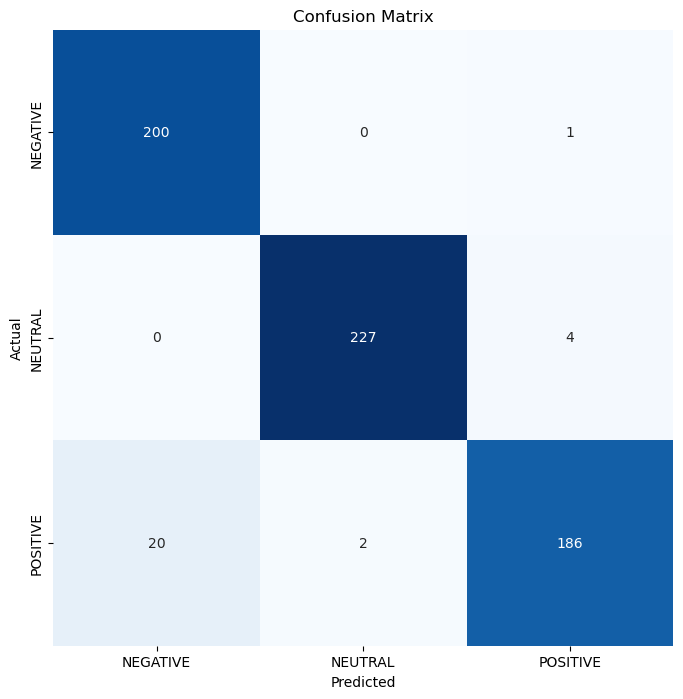

In [54]:
cm = confusion_matrix(y_test, y_pred)
clr = classification_report(y_test, y_pred, target_names=label_mapping.keys())

plt.figure(figsize=(8,8))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cbar=False, cmap='Blues')
plt.xticks(np.arange(3) + 0.5, label_mapping.keys())
plt.yticks(np.arange(3) + 0.5, label_mapping.keys())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [55]:
print("Classification Report:\n--------------------------\n", clr)

Classification Report:
--------------------------
               precision    recall  f1-score   support

    NEGATIVE       0.91      1.00      0.95       201
     NEUTRAL       0.99      0.98      0.99       231
    POSITIVE       0.97      0.89      0.93       208

    accuracy                           0.96       640
   macro avg       0.96      0.96      0.96       640
weighted avg       0.96      0.96      0.96       640

